# PyTorch fundamentals — Solutions

In [1]:
import numpy as np
import torch
import math
import matplotlib.pyplot as plt

## Level 1: NumPy (provided — no changes needed)

Result: y = 0.0427 + 0.8392x + -0.0074x² + -0.0908x³


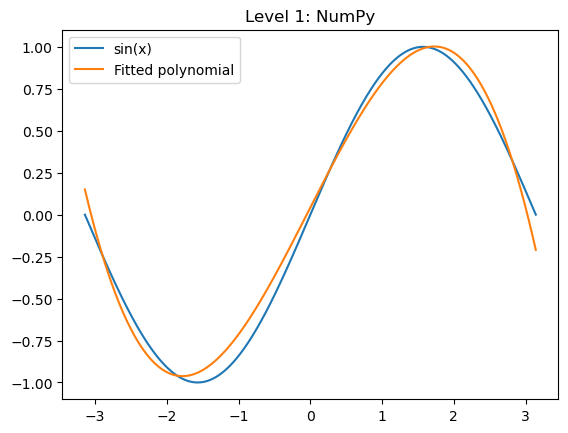

In [2]:
x_np = np.linspace(-math.pi, math.pi, 2000)
y_np = np.sin(x_np)

a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

learning_rate = 1e-6
for t in range(2000):
    y_pred = a + b * x_np + c * x_np**2 + d * x_np**3
    loss = np.square(y_pred - y_np).sum()
    grad_a = (2 * (y_pred - y_np)).sum()
    grad_b = (2 * (y_pred - y_np) * x_np).sum()
    grad_c = (2 * (y_pred - y_np) * x_np**2).sum()
    grad_d = (2 * (y_pred - y_np) * x_np**3).sum()
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f"Result: y = {a:.4f} + {b:.4f}x + {c:.4f}x² + {d:.4f}x³")
plt.plot(x_np, y_np, label="sin(x)")
plt.plot(x_np, a + b * x_np + c * x_np**2 + d * x_np**3, label="Fitted polynomial")
plt.legend()
plt.title("Level 1: NumPy")
plt.show()

## Level 2: PyTorch tensors

Result: y = -0.0211 + 0.8249x + 0.0036x² + -0.0888x³


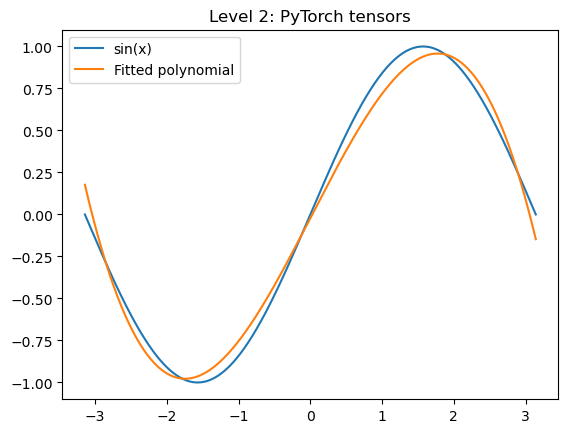

In [3]:
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)

a = torch.randn(())
b = torch.randn(())
c = torch.randn(())
d = torch.randn(())

learning_rate = 1e-6
for t in range(2000):
    y_pred = a + b * x + c * x**2 + d * x**3
    loss = (y_pred - y).pow(2).sum()

    grad_a = (2 * (y_pred - y)).sum()
    grad_b = (2 * (y_pred - y) * x).sum()
    grad_c = (2 * (y_pred - y) * x**2).sum()
    grad_d = (2 * (y_pred - y) * x**3).sum()

    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f"Result: y = {a:.4f} + {b:.4f}x + {c:.4f}x² + {d:.4f}x³")
plt.plot(x, y, label="sin(x)")
plt.plot(x, a + b * x + c * x**2 + d * x**3, label="Fitted polynomial")
plt.legend()
plt.title("Level 2: PyTorch tensors")
plt.show()

## Level 3: Autograd

In [4]:
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)

a = torch.randn((), requires_grad=True)
b = torch.randn((), requires_grad=True)
c = torch.randn((), requires_grad=True)
d = torch.randn((), requires_grad=True)

learning_rate = 1e-6
for t in range(2000):
    y_pred = a + b * x + c * x**2 + d * x**3
    loss = (y_pred - y).pow(2).sum()

    loss.backward()

    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f"Result: y = {a:.4f} + {b:.4f}x + {c:.4f}x² + {d:.4f}x³")

Result: y = -0.0418 + 0.8287x + 0.0072x² + -0.0893x³


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

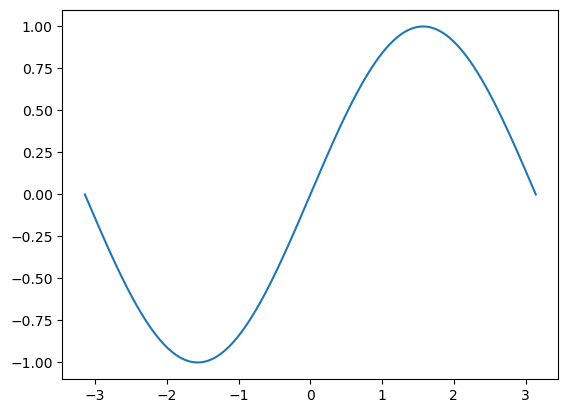

In [5]:
plt.plot(x, y, label="sin(x)")
plt.plot(x, a + b * x + c * x**2 + d * x**3, label="Fitted polynomial")
plt.legend()
plt.title("Level 3: Autograd")
plt.show()

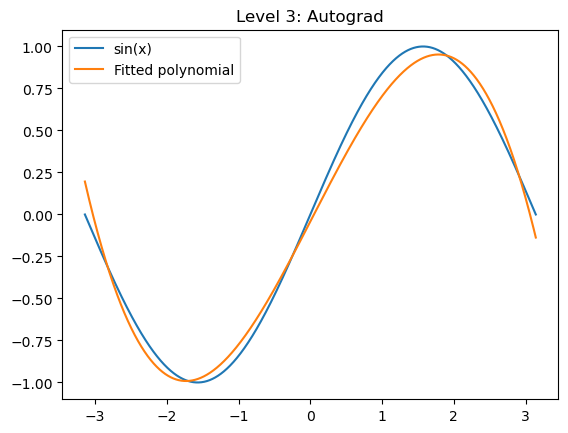

In [6]:
plt.plot(x.numpy(), y.numpy(), label="sin(x)")
with torch.no_grad():
    y_fit = a + b * x + c * x**2 + d * x**3
plt.plot(x.numpy(), y_fit.numpy(), label="Fitted polynomial")
plt.legend()
plt.title("Level 3: Autograd")
plt.show()

## Level 4: `nn` + `optim`

Result: y = -0.0039 + 0.8353x + 0.0007x² + -0.0903x³


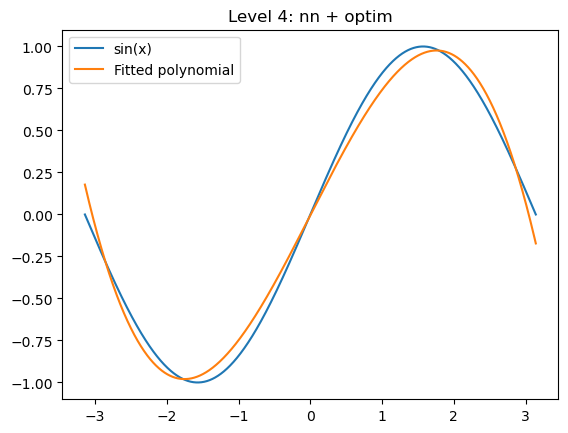

In [7]:
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)

# Prepare input: columns are [x, x², x³]
p = torch.tensor([1, 2, 3])
# unsqueeze adds a dimension: (2000,) → (2000, 1), then pow broadcasts to (2000, 3)
xx = x.unsqueeze(-1).pow(p)

# Model: a single linear layer (3 inputs → 1 output)
model = torch.nn.Sequential(
    torch.nn.Linear(3, 1),
    torch.nn.Flatten(0, 1),
)

loss_fn = torch.nn.MSELoss(reduction="sum")
optimizer = torch.optim.SGD(model.parameters(), lr=1e-6)

for t in range(2000):
    y_pred = model(xx)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

linear_layer = model[0]
w = linear_layer.weight.detach().flatten()
bias = linear_layer.bias.item()

print(f"Result: y = {bias:.4f} + {w[0]:.4f}x + {w[1]:.4f}x² + {w[2]:.4f}x³")

with torch.no_grad():
    y_fit = model(xx)
plt.plot(x.numpy(), y.numpy(), label="sin(x)")
plt.plot(x.numpy(), y_fit.numpy(), label="Fitted polynomial")
plt.legend()
plt.title("Level 4: nn + optim")
plt.show()